# General Task Performance 

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import (
    ACS_TASKS,
    TABLESHIFT_TASKS,
    BASELINES,
    FIGURES_ROOT_DIR,
)

from monoculture.analysis.utils import (
    load_model_outputs_same_prompt,
    load_results_overview,
    add_evals_to_df,
    load_data_if_needed,
    filter_results,
    filter_models_better_const,
    df_to_dict,
)
from monoculture.baseline.utils import load_baselines

from monoculture.analysis.plotting import (
    plot_accuracies,
    plot_label_dist,
    plot_general_performance_task,
)

In [3]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

FIGURES_PAPER_DIR = FIGURES_ROOT_DIR / "paper" / "same-prompt"
TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

tasks ('ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


In [13]:
select_by= 'balanced_accuracy' #'accuracy' # 

## Load Task Data

In [14]:
try:
    data_all
except NameError:
    print("'data_all' not yet defined")
    data_all = load_data_if_needed(data=None, tasks=TASKS)
else:
    print("Already defined, update if needed.")
    data_all = load_data_if_needed(data=data_all, tasks=TASKS)

Already defined, update if needed.


## Load Baselines

In [15]:
baseline_scores, baseline_evals = load_baselines(baselines=BASELINES, tasks=TASKS)

baseline_predictions = {
    task: baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in TASKS
}
baseline_predictions["ACSIncome"].head()

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/model-Constant/Constant_task-ACSIncome/Constant_bench-211220205'.
- LogisticRegression: Load predictions from 'results/baselines/model-LogisticRegression/LogisticRegression_task-ACSIncome/LogisticRegression_bench-790429520'.
- GBM: Load predictions from 'results/baselines/model-GBM/GBM_task-ACSIncome/GBM_bench-996001762'.
- XGBoost: Load predictions from 'results/baselines/model-XGBoost/XGBoost_task-ACSIncome/XGBoost_bench-3794332052'.
- NN: Load predictions from 'results/baselines/model-NN/NN_task-ACSIncome/NN_bench-276142988'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/model-Constant/Constant_task-ACSEmployment/Constant_bench-1469218015'.
- LogisticRegression: Load predictions from 'results/baselines/model-LogisticRegression/LogisticRegression_task-ACSEmployment/LogisticRegression_bench-2439278790'.
- GBM: Load predictions from 'results/baselines/model-

,Constant,LogisticRegression,GBM,XGBoost,NN
238351,0,0,0,0,0
2995677,0,0,0,0,0
2360043,0,0,1,1,1
1924596,0,0,0,0,0
2803585,0,0,0,0,0


In [16]:
print(f"{'baseline':20} & " + " & ".join(TASKS) + "\\\\")
for baseline in BASELINES:
    row = f"{baseline:20} & "
    for task in TASKS:
        row += f"\t{baseline_evals[task][baseline]['balanced_accuracy']:.4f} & "
    print(row[:-2] + "\\\\")

baseline             & ACSIncome & ACSEmployment & ACSMobility & ACSTravelTime & ACSPublicCoverage & BRFSS_Diabetes & BRFSS_Blood_Pressure\\
Constant             & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 \\
LogisticRegression   & 	0.7116 & 	0.7857 & 	0.5164 & 	0.5235 & 	0.5859 & 	0.5253 & 	0.6423 \\
GBM                  & 	0.7952 & 	0.8329 & 	0.5980 & 	0.6663 & 	0.7114 & 	0.5668 & 	0.6607 \\
XGBoost              & 	0.7995 & 	0.8336 & 	0.6055 & 	0.6859 & 	0.7193 & 	0.5710 & 	0.6612 \\
NN                   & 	0.7740 & 	0.8299 & 	0.5516 & 	0.6076 & 	0.6809 & 	0.5322 & 	0.6519 \\


## Load predictions

In [17]:
num_shots = 0

df_fitted = load_results_overview(
    num_shots=num_shots, threshold_fitted=True, same_prompt=True
)
df_fitted = df_fitted[df_fitted["task"].isin(TASKS)]
df_fitted = add_evals_to_df(
    df_fitted,
    metrics=["fpr", "fnr", "n_samples", "num_pred_negatives"],
)

df_unfitted = load_results_overview(
    num_shots=num_shots, threshold_fitted=False, same_prompt=True
)
df_unfitted = df_unfitted[df_unfitted["task"].isin(TASKS)]
df_unfitted = add_evals_to_df(
    df_unfitted,
    metrics=["fpr", "fnr", "n_samples", "num_pred_negatives"],
)

In [18]:
try:
    assert set(TASKS).issubset(
        set(df_fitted["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_fitted['task'].unique())} "
except AssertionError:
    TASKS = list(df_fitted["task"].unique())
    logging.warning(f"Reduced TASKS to available tasks: {TASKS}")

In [19]:
predictions_all_fitted = load_model_outputs_same_prompt(
    df_fitted, tasks=TASKS, return_risk_scores=False
)
predictions_all_unfitted = load_model_outputs_same_prompt(
    df_unfitted, tasks=TASKS, return_risk_scores=False
)

ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure
ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


## Fitted Threshold vs. not fitted

ACSIncome
Using balanced_accuracy for comparison.
Using balanced_accuracy for comparison.


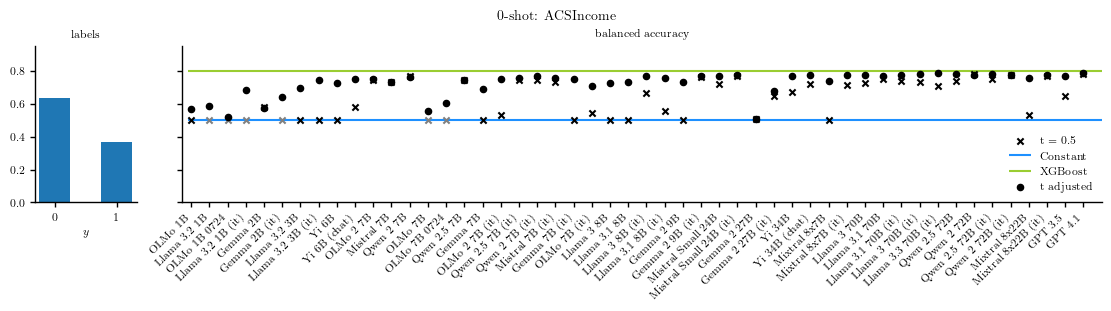

ACSEmployment
Using balanced_accuracy for comparison.
Using balanced_accuracy for comparison.


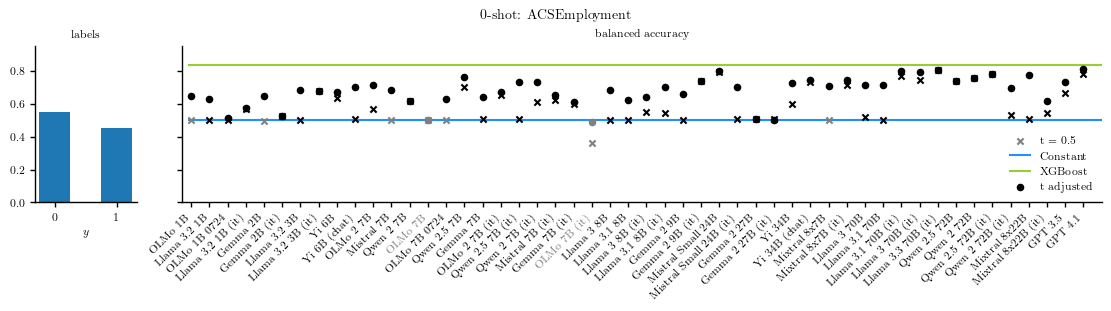

ACSMobility
Using balanced_accuracy for comparison.
Using balanced_accuracy for comparison.


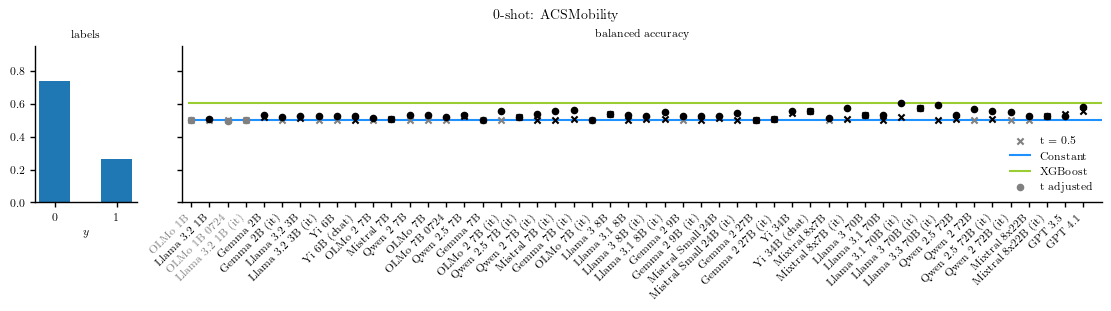

ACSTravelTime
Using balanced_accuracy for comparison.
Using balanced_accuracy for comparison.


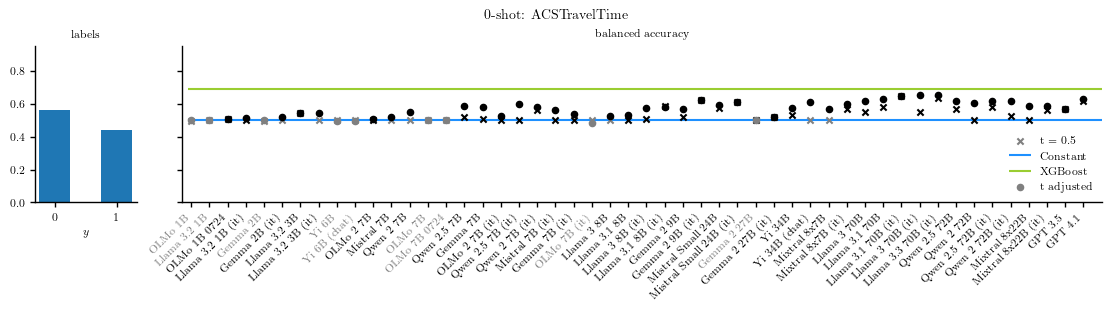

ACSPublicCoverage
Using balanced_accuracy for comparison.
Using balanced_accuracy for comparison.


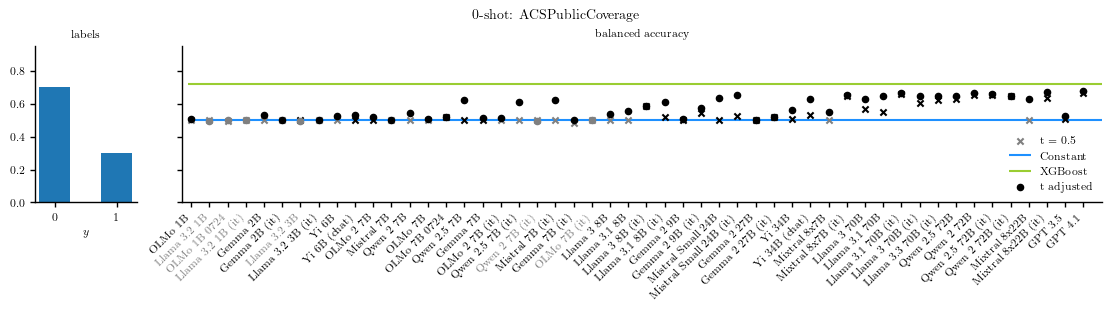

BRFSS_Blood_Pressure
Using balanced_accuracy for comparison.
Using balanced_accuracy for comparison.


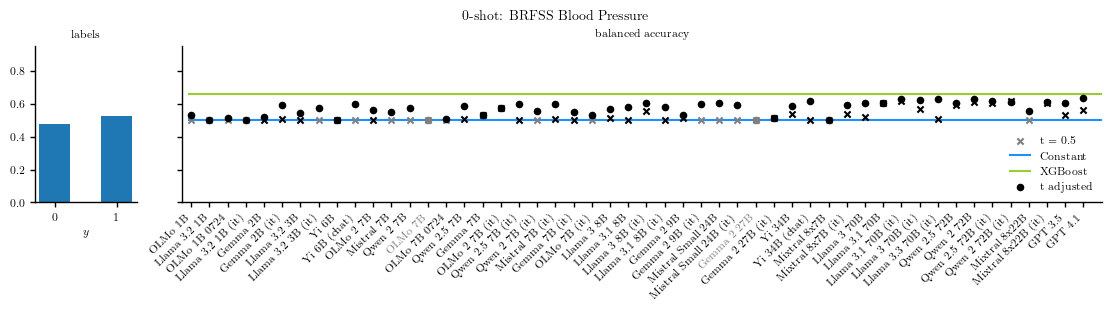

In [20]:
# one plot per task
tasks_to_plot = [task for task in TASKS if task != "BRFSS_Diabetes"]

fig_width = 2 * plt.rcParams["figure.figsize"][0]
fig_height = plt.rcParams["figure.figsize"][1]

for i, task in enumerate(tasks_to_plot):
    print(task)

    fig, axs = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(fig_width, fig_height),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 9]},
        sharey="row",
    )

    if len(axs) == 3:
        ax_label, ax_accuracy, ax_frac_neg = axs
    else:
        ax_label, ax_accuracy = axs
    mask_fitted = (df_fitted["task"] == task) & (
        df_fitted["model"].isin(predictions_all_fitted[task].columns)
    )
    mask_unfitted = (df_unfitted["task"] == task) & (
        df_unfitted["model"].isin(predictions_all_unfitted[task].columns)
    )

    y_true = data_all[task][1]
    num_models = df_fitted[mask_fitted].shape[0]
    # unfitted
    models_better_const_unfitted = filter_models_better_const(
        df_unfitted[df_unfitted["task"] == task], y_true=y_true, acc=select_by
    )
    acc_dict = df_to_dict(df_unfitted[mask_unfitted][["model", select_by]])
    plot_accuracies(
        ax_accuracy,
        evals=acc_dict,
        baseline_accs=None,
        models_above_baseline=models_better_const_unfitted,
        hline_xmin=-0.2,
        hline_xmax=num_models + 0.1,
        marker="x",
        scatter_label="t = 0.5",
    )
    # fitted:
    models_better_const_fitted = filter_models_better_const(
        df_fitted[df_fitted["task"] == task], y_true=y_true, acc=select_by
    )
    plot_general_performance_task(
        axs,
        df=df_fitted[mask_fitted],
        baseline_evals=baseline_evals[task],
        ytrue=y_true,
        models_to_highlight=models_better_const_fitted,
        marker="o",
        scatter_label="t adjusted",
        acc = select_by, 
        label_rotation=45,
        ha='right'
    )

    fig.suptitle(f"{num_shots}-shot: {task.replace('_', ' ')}")
    axs[1].legend(loc="lower right")
    # set column titles
    titles = ["labels", select_by.replace('_', ' '), "fraction negative predicted"]
    for c in range(len(axs)):
        axs[c].set_title(titles[c])

    file_name = f"performance-{select_by.replace('_','-')}-fitted-vs-unfitted-{num_shots}-shot-{task}",
    plt.show()